<a href="https://colab.research.google.com/github/Minakshi654/DocSense--CNN-based-Document-Classifier/blob/main/Finetunning_for_coco_cola__3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import torch
print("GPU available:", torch.cuda.is_available())

import os
os.environ['KAGGLE_USERNAME'] = "Mina26052001"
os.environ['KAGGLE_KEY'] = "KGAT_489ce73d1954fddf31a7220f42233c7f"

!pip install kaggle -q
print("Kaggle credentials set")

GPU available: True
Kaggle credentials set


In [3]:
!kaggle datasets download -d snap/amazon-fine-food-reviews

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
100% 242M/242M [00:01<00:00, 134MB/s]



In [4]:
!unzip -o amazon-fine-food-reviews.zip -d food_reviews
!ls food_reviews

Archive:  amazon-fine-food-reviews.zip
  inflating: food_reviews/Reviews.csv  
  inflating: food_reviews/database.sqlite  
  inflating: food_reviews/hashes.txt  
database.sqlite  hashes.txt  Reviews.csv


In [5]:
import pandas as pd

reviews_df = pd.read_csv("food_reviews/Reviews.csv")
print(reviews_df.shape)
print(reviews_df.head())
print("\nColumns:", reviews_df.columns.tolist())

(568454, 10)
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality can

In [6]:
# Search Text and Summary for beverage-related keywords
beverage_keywords = ["soda", "cola", "juice", "drink", "beverage", "soft drink", "coke", "pepsi", "sparkling"]

pattern = "|".join(beverage_keywords)
beverage_mask = reviews_df["Text"].str.contains(pattern, case=False, na=False) | \
                 reviews_df["Summary"].str.contains(pattern, case=False, na=False)

beverage_reviews = reviews_df[beverage_mask].copy()
print("Beverage-related reviews found:", len(beverage_reviews))
print("\nScore distribution:")
print(beverage_reviews["Score"].value_counts().sort_index())

Beverage-related reviews found: 99889

Score distribution:
Score
1     7964
2     5770
3     8451
4    16110
5    61594
Name: count, dtype: int64


In [7]:
# Convert 1-5 star rating into 3-class sentiment: negative, neutral, positive
def score_to_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

beverage_reviews["sentiment"] = beverage_reviews["Score"].apply(score_to_sentiment)
print(beverage_reviews["sentiment"].value_counts())

# Balance classes by taking an equal-sized sample from each (undersampling the majority)
min_class_size = beverage_reviews["sentiment"].value_counts().min()
print("\nSmallest class size:", min_class_size)

balanced_reviews = (
    beverage_reviews.groupby("sentiment")
    .apply(lambda x: x.sample(min(len(x), 2000), random_state=42))  # cap at 2000 per class for fast training
    .reset_index(drop=True)
)

print("\nBalanced dataset:")
print(balanced_reviews["sentiment"].value_counts())
print("Total:", len(balanced_reviews))

sentiment
positive    77704
negative    13734
neutral      8451
Name: count, dtype: int64

Smallest class size: 8451

Balanced dataset:
sentiment
negative    2000
neutral     2000
positive    2000
Name: count, dtype: int64
Total: 6000


/tmp/ipykernel_999/3812685144.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 2000), random_state=42))  # cap at 2000 per class for fast training


In [8]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced_reviews, test_size=0.2, stratify=balanced_reviews["sentiment"], random_state=42
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("\nTrain sentiment distribution:")
print(train_df["sentiment"].value_counts())

Train: (4800, 11)
Test: (1200, 11)

Train sentiment distribution:
sentiment
positive    1600
neutral     1600
negative    1600
Name: count, dtype: int64


In [9]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

label_map = {"negative": 0, "neutral": 1, "positive": 2}

train_df = train_df.copy()
test_df = test_df.copy()
train_df["label"] = train_df["sentiment"].map(label_map)
test_df["label"] = test_df["sentiment"].map(label_map)

from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df[["Text", "label"]].rename(columns={"Text": "text"}))
test_dataset = Dataset.from_pandas(test_df[["Text", "label"]].rename(columns={"Text": "text"}))

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized = test_tokenized.rename_column("label", "labels")
train_tokenized = train_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

print(train_tokenized)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4800
})


In [11]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [12]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False  # proactive fix, known issue from this morning

# Clean up the stray index column
if "__index_level_0__" in train_tokenized.column_names:
    train_tokenized = train_tokenized.remove_columns(["__index_level_0__"])
if "__index_level_0__" in test_tokenized.column_names:
    test_tokenized = test_tokenized.remove_columns(["__index_level_0__"])

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

training_args = TrainingArguments(
    output_dir="./sentiment_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("Trainer ready, num_labels=3")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer ready, num_labels=3


In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.650533,0.616868,0.745833,0.748221
2,0.542948,0.631388,0.735833,0.736240
3,0.352913,0.606742,0.768333,0.769773


TrainOutput(global_step=900, training_loss=0.5603379970126682, metrics={'train_runtime': 352.7607, 'train_samples_per_second': 40.821, 'train_steps_per_second': 2.551, 'total_flos': 953782279372800.0, 'train_loss': 0.5603379970126682, 'epoch': 3.0})

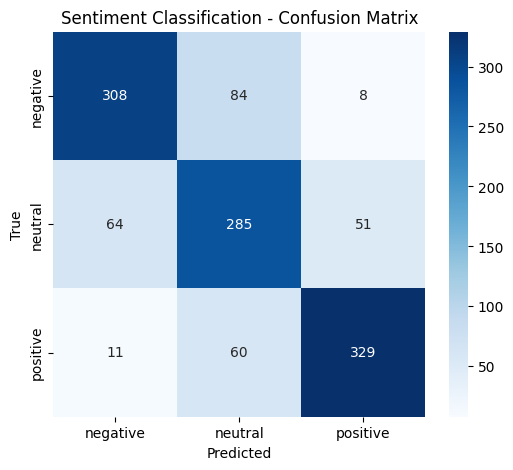

              precision    recall  f1-score   support

    negative       0.80      0.77      0.79       400
     neutral       0.66      0.71      0.69       400
    positive       0.85      0.82      0.84       400

    accuracy                           0.77      1200
   macro avg       0.77      0.77      0.77      1200
weighted avg       0.77      0.77      0.77      1200



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

predictions = trainer.predict(test_tokenized)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

class_names = ["negative", "neutral", "positive"]
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Sentiment Classification - Confusion Matrix")
plt.show()

print(classification_report(labels, preds, target_names=class_names))

In [16]:
model.save_pretrained("coca_cola_sentiment_distilbert")
tokenizer.save_pretrained("coca_cola_sentiment_distilbert")

!zip -r coca_cola_sentiment_distilbert.zip coca_cola_sentiment_distilbert

from google.colab import files
files.download("coca_cola_sentiment_distilbert.zip")

print("Model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: coca_cola_sentiment_distilbert/ (stored 0%)
  adding: coca_cola_sentiment_distilbert/model.safetensors (deflated 8%)
  adding: coca_cola_sentiment_distilbert/config.json (deflated 52%)
  adding: coca_cola_sentiment_distilbert/tokenizer_config.json (deflated 43%)
  adding: coca_cola_sentiment_distilbert/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved


# Component 3 — Consumer Sentiment Engine (Fine-tuned DistilBERT)

Part of the Coca-Cola Demand Intelligence & Market Insights Platform. A fine-tuned 3-class sentiment classifier trained on real beverage-related Amazon reviews, providing the consumer sentiment signal for the platform's market intelligence outputs.

## Objective

Classify consumer reviews of beverage products into negative, neutral, or positive sentiment, using a real, large-scale review dataset filtered to beverage-relevant content — extending an earlier binary sentiment fine-tuning project to a genuinely harder 3-class problem with real-world class imbalance to address.

## Dataset

- **Source:** Kaggle — "Amazon Fine Food Reviews" (`snap/amazon-fine-food-reviews`), a well-known Stanford SNAP dataset of ~500,000 real Amazon food reviews spanning 10+ years
- **Filtered to beverages:** keyword-filtered (soda, cola, juice, drink, beverage, soft drink, coke, pepsi, sparkling) down to 99,889 beverage-relevant reviews
- **Class imbalance addressed deliberately:** raw data was 62% positive (5-star), 24% negative (1-2 star), 14% neutral (3-star) — left unaddressed, this would let a model reach ~62% accuracy by always predicting "positive" without learning anything real. Balanced via undersampling to exactly 2,000 reviews per class (6,000 total)
- **Stratified train/test split** (4,800 / 1,200) preserving equal class proportions in both sets

## Approach

- Fine-tuned `distilbert-base-uncased` for 3-class sequence classification (negative / neutral / positive)
- 3 epochs, learning rate 2e-5, batch size 16
- Evaluated with both accuracy and **macro F1-score** (equally weighting all 3 classes), a more rigorous metric than accuracy alone when class-level performance might vary

## Results

- **Test accuracy: 76.83%**, macro F1: 0.77
- Per-class performance confirms a specific, well-understood pattern in sentiment analysis:

| Class | Precision | Recall | F1-score |
|---|---|---|---|
| Negative | 0.80 | 0.77 | 0.79 |
| Neutral | 0.66 | 0.71 | 0.69 |
| Positive | 0.85 | 0.82 | 0.84 |

## Key finding — errors cluster at sentiment boundaries, not between extremes

The confusion matrix shows the model's errors are heavily concentrated around the neutral class boundary (84 negative→neutral, 64 neutral→negative, 60 neutral→positive, 51 positive→neutral), while direct confusion between the two sentiment extremes is rare (only 19 negative↔positive errors combined, out of 1,200 test examples). This confirms a well-documented pattern in sentiment analysis literature: the model reliably distinguishes sentiment *direction* (the difference between negative and positive language is almost never missed) but struggles specifically with sentiment *intensity* at the boundary between mild sentiment and neutrality — a genuine, explainable limitation rather than a modeling failure.

## Comparison to prior binary sentiment project

| Metric | Binary sentiment (prior project) | 3-class sentiment (this project) |
|---|---|---|
| Training examples | 800 | 4,800 |
| Classes | 2 (positive/negative) | 3 (negative/neutral/positive) |
| Test accuracy | 86% | 76.8% |
| Class balance | Natural (not explicitly balanced) | Deliberately balanced via undersampling |

The lower headline accuracy here reflects genuine task difficulty, not weaker methodology — 3-class sentiment with an explicit neutral category is a recognized harder problem, and the deliberate class-balancing step (absent in the simpler prior project) makes this accuracy figure a more honest measure of real classification skill.

## What I'd improve next

- Address class imbalance via class-weighted loss instead of undersampling, to retain more of the available training data (99K reviews available vs. 6K used)
- Add a confidence threshold for the neutral class specifically, routing low-confidence predictions to human review in a production setting
- Fine-tune on review *Summary* text in addition to full review *Text*, since summaries are shorter and may carry clearer sentiment signal

## Tech stack

`Python` · `PyTorch` · `Hugging Face Transformers` · `Hugging Face Datasets` · `evaluate` · `scikit-learn` · `pandas` · Kaggle API · Google Colab (T4 GPU)

## How to run

1. Open `03_coca_cola_sentiment_engine.ipynb` in Google Colab
2. Add your Kaggle API credentials
3. Run all cells in order